In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from sklearn.linear_model import Ridge
import pandas as pd
%matplotlib inline

In [2]:
data_path = "/home/thappe/data/"

In [3]:
ls /home/thappe/data/ 

1940-2023_T2M_westEU_JJA.nc
LinRegrDetrendedperGridpoint_MSLP_era5_NHmidlats_0.25degr_1940_2023_JJA.nc
MSLP_era5_NHmidlats_0.25degr_1940_2023_JJA.nc*
NASA_GMST.csv
STREAM500_era5_ExtendedWestEU_0.25degr_1940_2022_JJA.nc


##  ERA5 Data

In [4]:
T2M_file = "1940-2023_T2M_westEU_JJA.nc"
STREAM500_file = "STREAM500_era5_ExtendedWestEU_0.25degr_1940_2022_JJA.nc"

In [5]:
t2m = xr.open_dataset(f"{data_path}{T2M_file}")
stream500 = xr.open_dataset(f"{data_path}{STREAM500_file}")

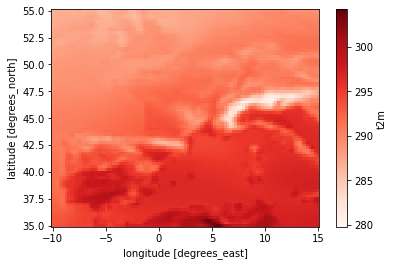

In [6]:
t2m_climatology = t2m['t2m'].mean(dim="time")
t2m_climatology.plot(cmap="Reds")


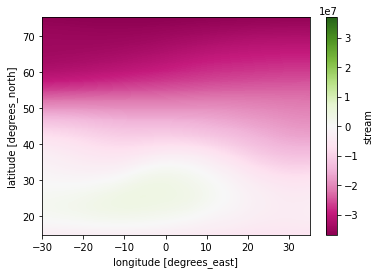

In [7]:
stream500_clim = stream500['stream'].mean(dim="time")
stream500_clim.plot(cmap="PiYG")


## NASA yearly GMST --> moet dit nog grotere lowess?

Perhaps a sensitivity test later on lowess=50 or so

In [6]:
yearly_GMST = pd.read_csv(f"{data_path}NASA_GMST.csv", delimiter=";", skiprows=1, index_col=0)

<AxesSubplot:xlabel='Year'>

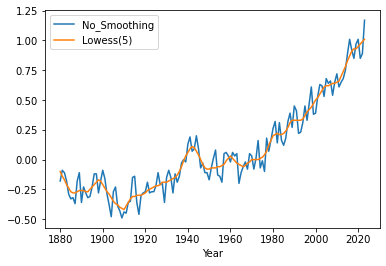

In [7]:
yearly_GMST.plot()

## prepare data for one grid point first

Text(0.5, 1.0, 'T2M gridpoint to predict \n and extent for dynamics')

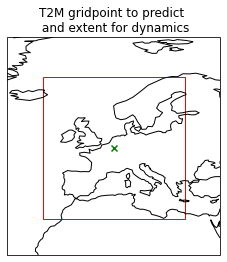

In [8]:
lon = 5
lat = 50
window=20 #sensitiity is relatively low 

lower_year = 1940 #(including)
upper_year = 2022 #(including)

standardize = True #whether to standardize the in and output data with respect to time axis (per gridpoint!)


lon_bounds = (lon-window, lon+window)
lat_bounds = (lat-window, lat+window)

## plot
import matplotlib.patches as mpatches

fig,ax = plt.subplots(nrows=1, ncols=1, figsize=(6,4), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([lon-(window+10), lon+(window+10), lat-(window+10), lat+(window+10)])
ax.add_patch(mpatches.Rectangle(xy=[lon_bounds[0],lat_bounds[0]], width=window*2, height=window*2,
                                facecolor='none', edgecolor='red',
                                transform=ccrs.PlateCarree()))
ax.coastlines()
ax.scatter(lon,lat, transform=ccrs.PlateCarree(), color='g', marker='x')
plt.title("T2M gridpoint to predict \n and extent for dynamics")

In [9]:
t2m_cut = t2m["t2m"].sel(time=t2m["t2m"].time.dt.year>= lower_year)
t2m_cut= t2m_cut.sel(time=t2m_cut.time.dt.year<= upper_year)
t2m_cut = t2m_cut.sel(longitude=lon, latitude=lat)

##### convert to xarray to have same shape as stream500 (later update to include 2024)

In [10]:
## this is from 1940-2023, JJA (92 days)
LOWESS5y_yearly_GMST = yearly_GMST["Lowess(5)"][-83:].to_numpy() ## select 1940-2022

GMST_reshaped = np.empty(7636,) #empty array with shape of number of days (e.g 92 per summer, per year)

for i, GMST in enumerate(LOWESS5y_yearly_GMST): ## loop over the GMST data to fill the array
    year_array = np.array(92 * [GMST], dtype=float)
    GMST_reshaped[i*92:(i+1)*92] = year_array[:]
    
#create xarray 
GMST_xr = xr.DataArray(
    data=GMST_reshaped,
    dims=["time"],
    coords=dict(
        time=t2m_cut.time.dt.year,
    ),
    attrs=dict(
        description="Global Mean Surface Temperature anomalie from NASA, 5 year LOWESS",
        units="degC",
    ),
)

slicing here I had to flip latitudal axis because of the negative latidue axis 

In [11]:
stream500_cut = stream500['stream'].sel(
    longitude=slice(lon_bounds[0], lon_bounds[1]), latitude=slice(lat_bounds[1], lat_bounds[0]))

In [12]:
#maybe not needed, check the Glmnet functions 

if standardize:
    print("Standardize is True")
    ## t2m
    t2m_y = (t2m_cut - t2m_cut.mean()) / t2m_cut.std()
    ## GMST
    GSMT_x1 = (GMST_xr - GMST_xr.mean()) / GMST_xr.std()
    ## stream
    stream500_mean = stream500_cut.mean(dim="time")
    stream500_std = stream500_cut.std(dim="time")
    stream500_x2 = (stream500_cut - stream500_mean) /stream500_std
if not standardize:
    print("warning: data is not standardized")
    t2m_y = t2m_cut 
    GSMT_x1 = GMST_xr
    stream500_x2 = stream500_cut 
    
    

Standardize is True


###### how to stack?

In [13]:
# ## need to stack the data somehow into 1 xarray for x

# ## code from peter:
# def construct_X(self, variables, lags=[0]):
#         target_days = self._data['target']._seasonal.day.values
#         target_days = target_days[target_days >= np.max(lags)]
#         labels = []
#         columns = []
#         for variable in variables:
#             for lag in lags:
#                 y = self._data[variable].with_feature_dim().loc[:, target_days - lag, :]
#                 columns.append(y.values)
#                 labels += [f'{variable}_lag{lag}'] * y.shape[-1] 

#         return xr.DataArray(np.concatenate(columns, axis=-1).reshape(-1, len(labels)), dims=['time','feature'], 
#                                     coords=dict(time=self._data['time']._seasonal[:, target_days].values.flatten(), feature=np.array(labels).flatten()))


So I need x to be: (GMST=(time,), STREAM500=(time, lon, lat))

### basically you need to get (7636, 25921+1) with the +1 being the FIRST data point and that is GMST, and that also has that label 

In [13]:
labels = []
values = []

dict_vars = {"GMST":GSMT_x1, "STREAM500":stream500_x2}
time=stream500_x2.time

#empty array
values_concated = np.empty((time.shape[0], 1+(stream500_x2.shape[1]*stream500_x2.shape[2])))
labels_concated = np.empty((1+(stream500_x2.shape[1]*stream500_x2.shape[2])), dtype="U8")

labels_concated[0]="GMST"
labels_concated[1:]="STREAM500"

for i, timestep in enumerate(time):  
    #print(i, timestep.values)
    values_timestep = []
#     labels_timestep = []
    for var in dict_vars.keys():
        #print(var)
        y = dict_vars[var].values[i] #values for this specific timestep
        if var == "GMST":
            values_timestep.append(y)
#             labels_timestep.append(var)
        if var == "STREAM500":
            y = y.reshape(y.shape[0]*y.shape[1])
            for y_val in y:
                values_timestep.append(y_val)
#                 labels_timestep.append(var)
    #put in array     
    values_concated[i]=np.array(values_timestep)[:]
#     labels_concated[i]=np.array(labels_timestep)[:]
     

In [14]:
values_concated.shape
values_concated[0]

array([-0.59548062, -0.64978373, -0.64864212, ..., -1.29977751,
       -1.27898562, -1.25597012])

In [15]:
labels_concated

array(['GMST', 'STREAM50', 'STREAM50', ..., 'STREAM50', 'STREAM50',
       'STREAM50'], dtype='<U8')

In [16]:
time.shape

(7636,)

In [17]:
X_concated = xr.DataArray(values_concated, 
             dims=['time','feature'], 
            coords=dict(
                time=time, 
                feature=labels_concated)
            )


In [18]:
t2m_y_reshaped = t2m_y.values.reshape(7636, 1).astype("float64")

## ridge with module from github

https://github.com/3zhang/Python-Lasso-ElasticNet-Ridge-Regression-with-Customized-Penalties/blob/main/custom_enet_example.ipynb 

In [19]:
from custom_enet import CustomENet, CustomENetCV


In [20]:
from scipy.optimize import minimize_scalar
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
from statsmodels.api import OLS, add_constant
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import RepeatedKFold

In [21]:
## create penalties for different features

penalty = np.ones(X_concated.values.shape[1]) 
penalty[np.where(labels_concated=='GMST')] = 0 

In [22]:
penalty

array([0., 1., 1., ..., 1., 1., 1.])

In [27]:
## cross validaiton
cv = RepeatedKFold(n_splits=3, n_repeats=2, random_state=2023) #what does random state mean


In [34]:
cv

RepeatedKFold(n_repeats=2, n_splits=3, random_state=2023)

In [24]:
## also need to find optimal alpha value, where 0 is full ridge and 1 is lasso. 
##We put 0.1 to test now
l1_standard = 0.1

#### what are the alphas again?
"In contrast to sklearn's ElasticNet, CustomENet and CustomENet incorporate Ridge regression. Simply set l1_ratio to 0. But for Ridge we need to provide the alphas."

alphas = np.geomspace(0.01, 10, num=100)

dan kan je mse voor de verschillende alphas plotten:
 _ = path_stats(model_rd.alphas, model_rd.cv_errs, title='custom ridge mse')



In [35]:

model_ce = CustomENetCV(cv, l1_ratio=l1_standard, 
                        standardize=False, #already standardized
                        fit_intercept=False, #y is centered (standadized) 
                        alphas=None, 
                        tol=1e-4, #dec of coefficients
                        max_iter=10,) #needs 5000 misschien minder maar even om de code te testen
                        #random_state=2023)

In [36]:
X_ = X_concated.values.astype("float32")
Y_ = t2m_y_reshaped

model_ce.fit(X_, Y_, penalty)

CV round 1


/home/thappe/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1.2469428099966535, tolerance: 0.4865654016044001
  model = cd_fast.enet_coordinate_descent_gram(
/home/thappe/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1.4939345083430453, tolerance: 0.4865654016044001
  model = cd_fast.enet_coordinate_descent_gram(
/home/thappe/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1.231407161372772, tolerance: 0.4865654016044001
  model = cd_fast.enet_coordinate_descent_gram(
/home/thappe/.local/lib/python3.10/site-packages/sklearn/linear_model/_

/home/thappe/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 2.577943153541355, tolerance: 0.4865654016044001
  model = cd_fast.enet_coordinate_descent_gram(
/home/thappe/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 3.057491134397196, tolerance: 0.4865654016044001
  model = cd_fast.enet_coordinate_descent_gram(
/home/thappe/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 3.5701120720318613, tolerance: 0.4865654016044001
  model = cd_fast.enet_coordinate_descent_gram(
/home/thappe/.local/lib/python3.10/site-packages/sklearn/linear_model/_c

/home/thappe/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 3.0954365310126377, tolerance: 0.4865654016044001
  model = cd_fast.enet_coordinate_descent_gram(
/home/thappe/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 3.175348046403542, tolerance: 0.4865654016044001
  model = cd_fast.enet_coordinate_descent_gram(
/home/thappe/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 3.2140565111058095, tolerance: 0.4865654016044001
  model = cd_fast.enet_coordinate_descent_gram(
/home/thappe/.local/lib/python3.10/site-packages/sklearn/linear_model/_

/home/thappe/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 23.690765510714527, tolerance: 0.4865654016044001
  model = cd_fast.enet_coordinate_descent_gram(
/home/thappe/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 30.781019076202483, tolerance: 0.4865654016044001
  model = cd_fast.enet_coordinate_descent_gram(
/home/thappe/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 37.944043196649545, tolerance: 0.4865654016044001
  model = cd_fast.enet_coordinate_descent_gram(
/home/thappe/.local/lib/python3.10/site-packages/sklearn/linear_model/

...

CV round 6


/home/thappe/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.959217513326621, tolerance: 0.4991287572863801
  model = cd_fast.enet_coordinate_descent_gram(
/home/thappe/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.9169228809250853, tolerance: 0.4991287572863801
  model = cd_fast.enet_coordinate_descent_gram(
/home/thappe/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1.954049813124584, tolerance: 0.4991287572863801
  model = cd_fast.enet_coordinate_descent_gram(
/home/thappe/.local/lib/python3.10/site-packages/sklearn/linear_model/_c

/home/thappe/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1.9990594823573247, tolerance: 0.4991287572863801
  model = cd_fast.enet_coordinate_descent_gram(
/home/thappe/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 2.4202176563810553, tolerance: 0.4991287572863801
  model = cd_fast.enet_coordinate_descent_gram(
/home/thappe/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 3.0364301120371238, tolerance: 0.4991287572863801
  model = cd_fast.enet_coordinate_descent_gram(
/home/thappe/.local/lib/python3.10/site-packages/sklearn/linear_model/

/home/thappe/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 4.749349284948721, tolerance: 0.4991287572863801
  model = cd_fast.enet_coordinate_descent_gram(
/home/thappe/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 4.747829873932687, tolerance: 0.4991287572863801
  model = cd_fast.enet_coordinate_descent_gram(
/home/thappe/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 4.61857859080078, tolerance: 0.4991287572863801
  model = cd_fast.enet_coordinate_descent_gram(
/home/thappe/.local/lib/python3.10/site-packages/sklearn/linear_model/_coo

/home/thappe/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 18.760895868146463, tolerance: 0.4991287572863801
  model = cd_fast.enet_coordinate_descent_gram(
/home/thappe/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 24.219521671337134, tolerance: 0.4991287572863801
  model = cd_fast.enet_coordinate_descent_gram(
/home/thappe/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 33.54637458264415, tolerance: 0.4991287572863801
  model = cd_fast.enet_coordinate_descent_gram(
/home/thappe/.local/lib/python3.10/site-packages/sklearn/linear_model/_

In [37]:
model_ce

In [39]:
y_pred = model_ce.predict(X_).reshape(-1, 1)
print("MSE is:", mean_squared_error(Y_, y_pred, squared=False))

MSE is: 0.5146188543329501


/home/thappe/.local/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [42]:
weights = model_ce.w

In [45]:
GMSTw = weights[0]
stream_weigths = weights[1:]

In [48]:
stream_weigths_reshaped = stream_weigths.reshape(161,161)

In [53]:
stream_weigths_reshaped.max()


0.07993676684442316

Text(0.5, 1.0, 'Coefficients of dynamical part of the regression \n for T2M in gridpoint denoted with X')

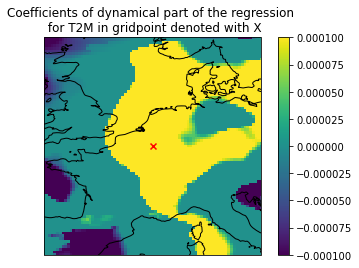

In [64]:
fig,ax = plt.subplots(nrows=1, ncols=1, figsize=(6,4), 
                      subplot_kw={'projection': ccrs.PlateCarree()})

ax.set_extent([lon-(10), lon+(10), lat-(10), lat+(10)])
ax.add_patch(mpatches.Rectangle(xy=[lon_bounds[0],lat_bounds[0]], width=window*2, height=window*2,
                                facecolor='none', edgecolor='red',
                                transform=ccrs.PlateCarree()))
cs = ax.pcolormesh(stream500_cut.longitude, stream500_cut.latitude, 
              stream_weigths_reshaped,
             vmin=-0.0001, vmax=0.0001)
fig.colorbar(cs, ax=ax)

ax.coastlines()
ax.scatter(lon,lat, transform=ccrs.PlateCarree(), color='r', marker='x')
plt.title("Coefficients of dynamical part of the regression \n for T2M in gridpoint denoted with X")

In [67]:
## dus dan kun je daarna met de GMSTw de temperatuur eruit halen die 
## door thermodynamics komt, voor elke dag, en dan heb je de detrended timeseries voor t2m
print(np.sum(stream_weigths_reshaped))
GMSTw

0.5024589649399033


0.09929159523206797

## ridge/lasso code using Glmnet

https://glmnet-python.readthedocs.io/en/latest/glmnet_vignette.html#Linear-Regression

In [21]:
import glmnet_py
from glmnet import glmnet

In [22]:
from glmnet import glmnet; from glmnetPlot import glmnetPlot
from glmnetPrint import glmnetPrint; from glmnetCoef import glmnetCoef; from glmnetPredict import glmnetPredict
from cvglmnet import cvglmnet; from cvglmnetCoef import cvglmnetCoef
from cvglmnetPlot import cvglmnetPlot; from cvglmnetPredict import cvglmnetPredict

In [ ]:
#     x = self._X.values.astype('float64').copy(), 
#     y = self._target._x.values.astype('float64').copy(), 
#     penalty_factor=self._penalty.astype('float64').copy(), 

#### penalty_factor should be same shape as input X, with 0 for GMST and 1s for Stream500

Do cross validation to check the lambda that has the lowest MSE by selecting lambda-min, then after you use this lambda-min for the predictions. --> only use this for validation  AND for the coefficients



In [26]:
fitted = cvglmnet(
    x = X_concated.values.astype("float64"), 
    y = t2m_y_reshaped, 
    penalty_factor={"GMST":0}, 
    alpha = 0, #0.5., so full ridge 
    ptype = 'mse', 
    nfolds = 20,
    ) #    weights for the timesteps, so just 1. Perhaps you can put more weights on the last years to test? 


OSError: libgfortran.so.3: cannot open shared object file: No such file or directory

In [ ]:
# standardize data 
#for LAND grid point in t2m data == Y
#select the corresponding stream500 input fields (lon,lat bounds)  == X1
# get the GMST data for all years, shape this to (days,) == X2 
# train the ridge model 

## then you can get the coef_ for the GMST and take this out 

### code from Peter:
hieronder de echte fitting, hiervoor is al alle data prep gedaan

In [53]:
self._fit = cvglmnet(
    x = self._X.values.astype('float64').copy(), 
    y = self._target._x.values.astype('float64').copy(), 
    penalty_factor=self._penalty.astype('float64').copy(), 
    weights = weights.astype('float64').copy(),
    alpha = 0,
    ptype = 'mse', 
    nfolds = 20,
    )

<xarray.DataArray (time: 7728)>
array([0.06, 0.06, 0.06, ..., 1.01, 1.01, 1.01])
Coordinates:
  * time     (time) int64 1940 1940 1940 1940 1940 ... 2023 2023 2023 2023 2023
Attributes:
    description:  Global Mean Surface Temperature anomalie from NASA, 5 year ...
    units:        degC

In [ ]:
#The coefficients from the fit:
self._coefs = cvglmnetCoef(self._fit, s = scipy.float64([self._alpha]))[:,0]

In [ ]:
## predict:
reproduction[:] = cvglmnetPredict(self._fit, X, ptype = 'response', s = scipy.float64([self._alpha]))[:,0].squeeze()
##Then test the r2:
print(f"\nvariance explained: {explained_variance_score(self._target._x.values, self.reproduce(self._X)._x.values)}")
